# Training for New Data (engine_2)

In [1]:
import numpy as np
import os
import pandas as pd
import random
import yaml
import seaborn as sns

from src.electrical_signature_frequencies import ANOMALY_FREQS
from src.anomaly_injector import GaussianPeakInjector, NoiseInjector, CompositeAnomalyInjector
import matplotlib.pyplot as plt
from pathlib import Path

import torch

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set device 
device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)
print("Using device:", device)

Using device: mps


## Configuration

In [2]:
base_dir = "../dataset/engine_2"

# Load Engine Configuration
path2engine_cfg = os.path.join(base_dir, 'engine.yml')
with open(path2engine_cfg, 'r') as f:
    engine_config = yaml.safe_load(f)

engine_config

{'engine': {'motor_model': 'АИP 80B4 IM1081',
  'power': 1.5,
  'rpm': 1390,
  'voltage': '380V/50Hz',
  'efficiency': 78,
  'nominal_current': 6.39,
  'power_factor': 0.79,
  'bearings': '6204'},
 'mcsa': {'f1': 50,
  'f_sampling': 4098,
  's': 0.073,
  'R_s': None,
  'p': 2,
  'f_r': 23.17,
  'n': 8,
  'beta': 0,
  'D_pit': 34.5,
  'D_ball': 7.94}}

In [3]:
# Load Dataset Metadata
metadata_df = pd.read_csv(os.path.join(base_dir, 'metadata.csv'))
metadata_df.set_index('measurement_id', inplace=True)
metadata_df

,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,,,
1727864902_1,1727864902,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864862_1,1727864862,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864642_1,1727864642,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864722_1,1727864722,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864522_1,1727864522,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...,...,...
1727784570_2,1727784570,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784410_2,1727784410,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784610_2,1727784610,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml


In [4]:
print("Number of measurements for each state:")
metadata_df['state'].value_counts()

Number of measurements for each state:


state
bearing defect               417
rotor bar defect             408
normal                       384
inter-turn short circuits    231
Name: count, dtype: int64

In [5]:
# Load training and processing parameters
with open("../training_configs/train-engine-2.yml", "r") as f:
    train_params = yaml.safe_load(f)

# Processing Parameters
f_sampling = train_params["processing_parameters"]["f_sampling"]
shift = train_params["processing_parameters"]["shift"]
segment_length = train_params["processing_parameters"]["segment_length"]
cutoff_freq = train_params["processing_parameters"]["cutoff_freq"]
peak_type = train_params["processing_parameters"]["peak_type"]
peak_segment = train_params["processing_parameters"]["peak_segment"]
amplitude_range = tuple(train_params["processing_parameters"]["amplitude_range"])
sigma_range = tuple(train_params["processing_parameters"]["sigma_range"])
noise_factor = train_params["processing_parameters"]["noise_factor"]
include_negative_peaks = train_params["processing_parameters"]["include_negative_peaks"]
random_peak_position = train_params["processing_parameters"]["random_peak_position"]
fault_types_to_use = train_params["processing_parameters"]["fault_types_to_use"]
loads_to_use = train_params["processing_parameters"]["loads_to_use"]
phases_to_use = train_params["processing_parameters"]["phases_to_use"]

# Training Parameters
num_epochs_binary = train_params["training_parameters"]["num_epochs_binary"]
num_epochs_multi = train_params["training_parameters"]["num_epochs_multi"]

# Data Parameters
batch_size = train_params["data_parameters"]["batch_size"]

# Dataset Parameters
val_size = train_params["dataset_parameters"]["val_size"]
test_size = train_params["dataset_parameters"]["test_size"]
normalization_method = train_params["dataset_parameters"]["normalization_method"]

In [6]:
train_params

{'processing_parameters': {'f_sampling': 4098,
  'shift': 20,
  'segment_length': 10000,
  'cutoff_freq': 250,
  'peak_type': 'gaussian',
  'peak_segment': 10,
  'amplitude_range': [0.5, 20.0],
  'sigma_range': [0.5, 1.5],
  'noise_factor': 0.0,
  'include_negative_peaks': True,
  'random_peak_position': True,
  'fault_types_to_use': ['inter-turn short circuits', 'rotor bar defect'],
  'loads_to_use': [100],
  'phases_to_use': [1]},
 'training_parameters': {'num_epochs_binary': 20, 'num_epochs_multi': 20},
 'data_parameters': {'batch_size': 512},
 'dataset_parameters': {'test_size': 0.3,
  'val_size': 0.2,
  'normalization_method': 'min-max'}}

In [7]:
MCSA_cfg = {
    'rotor bar defect': {
        'engine_config': engine_config['mcsa'],
        'n_range': range(1, 4)
        },
    'inter-turn short circuits': {
        'engine_config': engine_config['mcsa'],
        'k_range': range(1, 4, 2), 
        'm_range': range(0, 2)
        },
    'bearing defect': {
        'engine_config': engine_config['mcsa']
        },
}

fault_freqs = {
    fault_type: ANOMALY_FREQS[fault_type](**MCSA_cfg[fault_type]) for fault_type in fault_types_to_use
}

fault_freqs

{'inter-turn short circuits': [26.83, 50.0, 73.17, 126.83, 150.0, 173.17],
 'rotor bar defect': [28.1, 35.4, 42.7, 57.3, 64.6, 71.9]}

In [8]:
# Instantiate the Gaussian injector
gaussian_injector = GaussianPeakInjector(
    peak_segment=peak_segment,
    amplitude_range=amplitude_range,
    sigma_range=sigma_range,
    negative=include_negative_peaks,
    random_peak_position=random_peak_position
)

# Instantiate the Noise injector
noise_injector = NoiseInjector(noise_factor=noise_factor)

# Combine the injectors
composite_injector = CompositeAnomalyInjector({
    'peak-anomaly': gaussian_injector,
    'noise': noise_injector
})

In [9]:
training_classes = fault_types_to_use + ['normal']

## Load Data

In [10]:
from tqdm.auto import tqdm

from src.data_pipeline import (
    segment_signal,
    perform_fft_on_segments,
    normalize_segment,
    load_measurement
)

import os
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, TensorDataset

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ 1.  PRE-PROCESSING                                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def preprocessing(
    metadata_df: pd.DataFrame,
    out_dir: str,
    segment_length: int,
    step: int,
    f_sampling: int,
    cutoff_freq: int,
    apply_window: bool = False,
    db: bool = True,
) -> Tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """
    Convert every measurement in *metadata_df* into FFT magnitude windows.

    Parameters
    ----------
    metadata_df : pd.DataFrame
        Measurement-level table produced by `create_metadata_df`.  **Must** be
        indexed by `"measurement_id"` and contain at least the columns:

            ["state", "phase", "load_condition", "experiment"]

    out_dir : str
        Destination directory for the three artefacts written to disk.

    segment_length : int
        Number of time-domain samples per window.

    step : int
        Hop-size (in samples) between consecutive windows.

    f_sampling : int
        Sampling frequency (Hz) used to compute the frequency vector.

    cutoff_freq : int
        Keep FFT bins only up to this frequency (Hz).

    apply_window : bool, optional
        If *True*, applies a Hann window to every slice before the FFT.
        Default = *False* (good enough for equally spaced integer cycles).

    db : bool, optional
        If *True*, returns magnitude in decibels.  Default = *True*.

    Returns
    -------
    segments : np.ndarray
        Dense float32 array of shape *(N_segments, segment_length)* holding the
        pre-processed FFT spectra.

    seg_meta_df : pd.DataFrame
        Segment-level metadata indexed by the **compound** key
        ``["measurement_id", "segment_idx"]`` - row order is **identical** to
        *segments*.

    freqs : np.ndarray
        1-D float64 array (length = *segment_length*) with the frequency bins
        (post cut-off).

    Notes
    -----
    * The function deliberately **does not** sort the DataFrame, preserving the
      original row order so that `segments[i]` <—> `seg_meta_df.iloc[i]`.
    """
    seg_rows: List[dict] = []
    seg_arrays: List[np.ndarray] = []
    freqs: Optional[np.ndarray] = None

    for m_id, meta in tqdm(metadata_df.iterrows(),
                           total=len(metadata_df),
                           desc="pre-processing"):
        # 1) Load the CSV
        df = load_measurement(m_id, metadata_df)
        current = df["Current"].dropna().values

        # 2) Time-domain slicing
        win_arr = segment_signal(
            current,
            segment_length=segment_length,
            step=step,
            apply_window=apply_window,
        )

        # 3) FFT magnitude spectra
        fft_arr, freqs = perform_fft_on_segments(
            win_arr,
            f_sampling=f_sampling,
            cutoff_freq=cutoff_freq,
            db=db,
        )

        # 4) Build a metadata row for every segment
        n_segments = fft_arr.shape[0]
        for s_idx in range(n_segments):
            start_t = df.index[s_idx * step]
            end_t   = df.index[s_idx * step + segment_length - 1]
            seg_rows.append({
                "measurement_id":  m_id,
                'base_id':         meta["base_id"],  
                "segment_idx":     s_idx,
                "start_time":      float(start_t),
                "end_time":        float(end_t),
                "state":           meta["state"],
                "binary_label":    0 if meta["state"] == "normal" else 1,
                "multiclass_label": meta["state"],
                "phase":           int(meta["phase"]),
                "load_condition":  meta["load_condition"],
                "experiment":      meta["experiment"],
            })
        seg_arrays.append(fft_arr.astype(np.float32))

    # 5) Concatenate and persist
    segments = np.vstack(seg_arrays)                              # shape = (N, L)
    seg_meta_df = pd.DataFrame(seg_rows).set_index(
        ["measurement_id", "segment_idx"]
    )

    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "segments.npy"), segments)
    np.save(os.path.join(out_dir, "freqs.npy"), freqs)
    seg_meta_df.to_csv(os.path.join(out_dir, "segments_metadata.csv"))

    return segments, seg_meta_df, freqs

In [12]:
metadata_df

,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,,,
1727864902_1,1727864902,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864862_1,1727864862,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864642_1,1727864642,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864722_1,1727864722,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864522_1,1727864522,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...,...,...
1727784570_2,1727784570,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784410_2,1727784410,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784610_2,1727784610,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml


In [13]:
segments, seg_meta_df, freqs = preprocessing(
    metadata_df      = metadata_df,
    out_dir          = "../dataset/engine_2/experiment_1",
    segment_length   = segment_length,
    step             = shift,
    f_sampling       = f_sampling,
    cutoff_freq      = cutoff_freq,
    apply_window     = False,
    db               = True
)

pre-processing:   0%|          | 0/1440 [00:00<?, ?it/s]

In [14]:
seg_meta_df

base_id   start_time     end_time  \
measurement_id segment_idx                                         
1727864902_1   0            1727864902     0.000000  2441.162109   
               1            1727864902     4.882812  2446.044922   
               2            1727864902     9.765625  2450.927734   
               3            1727864902    14.648438  2455.810547   
               4            1727864902    19.531250  2460.693359   
...                                ...          ...          ...   
1727784371_2   315          1727784371  1538.085938  3979.248047   
               316          1727784371  1542.968750  3984.130859   
               317          1727784371  1547.851562  3989.013672   
               318          1727784371  1552.734375  3993.896484   
               319          1727784371  1557.617188  3998.779297   

                                       state  binary_label  multiclass_label  \
measurement_id segment_idx                                                     
1727864902_1   0              bearing defect             1    bearing defect   
               1              bearing defect             1    bearing defect   
               2              bearing defect             1    bearing defect   
               3              bearing defect             1    bearing defect   
               4              bearing defect             1    bearing defect   
...                                      ...           ...               ...   
1727784371_2   315          rotor bar defect             1  rotor bar defect   
               316          rotor bar defect             1  rotor bar defect   
               317          rotor bar defect             1  rotor bar defect   
               318          rotor bar defect             1  rotor bar defect   
               319          rotor bar defect             1  rotor bar defect   

                            phase  load_condition    experiment  
measurement_id segment_idx                                       
1727864902_1   0                1              80  experiment_1  
               1                1              80  experiment_1  
               2                1              80  experiment_1  
               3                1              80  experiment_1  
               4                1              80  experiment_1  
...                           ...             ...           ...  
1727784371_2   315              2              40  experiment_1  
               316              2              40  experiment_1  
               317              2              40  experiment_1  
               318              2              40  experiment_1  
               319              2              40  experiment_1  

[460800 rows x 9 columns]

In [15]:
print("Segments:", segments.shape)
print("Metadata shape:", seg_meta_df.shape)

Segments: (460800, 611)
Metadata shape: (460800, 9)


In [16]:
segments0 = segments.copy()
seg_meta_df0 = seg_meta_df.copy()

## Filter Segments

In [17]:
# Filter states using fault_types_to_use with 'normal'
training_classes_mask = seg_meta_df['state'].isin(training_classes)

# Filter loads using loads_to_use
loads_mask = seg_meta_df['load_condition'].isin(loads_to_use)

# Filter phases using phases_to_use
phases_mask = seg_meta_df['phase'].isin(phases_to_use)

# Finall mask
mask = training_classes_mask & loads_mask & phases_mask

In [18]:
# Apply mask
segments = segments[mask]
seg_meta_df = seg_meta_df[mask]

### Datasets & DataLoaders

In [19]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ 2.  DATASET WITH ON-THE-FLY FAULT INJECTION                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class DynamicDataset(Dataset):
    """
    A PyTorch `Dataset` that *dynamically* balances the classes by injecting
    synthetic fault signatures into **normal** FFT windows with a user-defined
    probability *p_inject*.

    Behaviour
    ---------
    • If the original *state* == "normal"
        - With probability *p_inject* : replace window with a *synthetic* fault
        - With probability 1-*p_inject* : leave it normal
    • If the original *state* ≠ "normal"
        - Return window unchanged (authentic fault)

    Optional noise injection is performed **after** any synthetic fault
    generation so that SNR matches reality.

    Parameters
    ----------
    segments : np.ndarray
        FFT windows (N, L) - memory-mapped arrays work fine.

    seg_meta_df : pd.DataFrame
        Must be row-aligned with *segments* (see `preprocessing`).

    freqs : np.ndarray
        Frequency vector (L,).

    fault_freqs : Dict[str, np.ndarray]
        Mapping *fault_type* → array of characteristic fault frequencies
        (centre frequencies for Gaussian peaks).

    mode : {'binary', 'multiclass'}, default='binary'
        Governs target labels:
            binary     : 0 = normal, 1 = any fault
            multiclass : encoded with `LabelEncoder`

    normalization_method : {'min-max', 'z-score', None}, optional
        On-the-fly normalisation.  If *None*, raw dB magnitudes are returned.

    anomaly_injector : CompositeAnomalyInjector, optional
        Instance capable of injecting Gaussian peaks and/or additive noise.
        Must expose `.inject(segment, fft_freqs, fault_freqs, injector_keys)`.

    fault_injection_prob : float, default=0.5
        Probability *p* that a normal window is converted into a synthetic
        fault.

    label_encoder : LabelEncoder, optional
        Pre-fit encoder for multiclass mode.  If *None*, a new encoder is fit
        on *fault_freqs.keys() ∪ {'normal'}*.

    Returns
    -------
    Tuple[torch.Tensor, int]
        *Input*  : tensor with shape (1, L)
        *Target* : integer label (see *mode*)
    """

    def __init__(
        self,
        segments: np.ndarray,
        seg_meta_df: pd.DataFrame,
        freqs: np.ndarray,
        fault_freqs: Dict[str, np.ndarray],
        mode: str = "binary",
        normalization_method: Optional[str] = "min-max",
        anomaly_injector: Optional[Any] = None,
        fault_injection_prob: float = 0.5,
        label_encoder: Optional[LabelEncoder] = None,
    ) -> None:
        super().__init__()
        assert 0.0 <= fault_injection_prob <= 1.0, "probability must be in [0,1]"
        self.segments = segments
        self.seg_meta_df = seg_meta_df
        self.freqs = freqs
        self.anomaly_injector = anomaly_injector
        self.mode = mode
        self.norm_method = normalization_method
        self.p_inject = float(fault_injection_prob)

        # fault taxonomy
        self.fault_freqs = fault_freqs
        self.fault_types = sorted(list(fault_freqs.keys()))

        # encoder for multiclass
        if mode == "multiclass":
            if label_encoder is None:
                label_encoder = LabelEncoder().fit(self.fault_types + ["normal"])
            self.le = label_encoder
        else:
            self.le = None

    def __len__(self) -> int:
        return len(self.segments)

    def _choose_label_for_normal(self) -> str:
        """Randomly decide whether a normal window becomes a fault."""
        if np.random.rand() < self.p_inject:
            return np.random.choice(self.fault_types)
        return "normal"

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        seg = self.segments[idx].copy()          # (L,)
        meta = self.seg_meta_df.iloc[idx]
        orig_label = meta["state"]

        # ── 1. maybe inject fault if originally normal ─────────────────
        if orig_label == "normal":
            chosen_label = self._choose_label_for_normal()
            if chosen_label != "normal" and self.anomaly_injector is not None:
                seg = self.anomaly_injector.inject(
                    segment       = seg,
                    fft_freqs     = self.freqs,
                    fault_freqs   = self.fault_freqs[chosen_label],
                    injector_keys = ["peak-anomaly"]
                )
        else:
            chosen_label = orig_label  # keep authentic fault

        # ── 2. optional noise injection ────────────────────────────────
        if self.anomaly_injector is not None and "noise" in self.anomaly_injector.injectors:
            seg = self.anomaly_injector.inject(
                segment       = seg,
                fft_freqs     = self.freqs,
                fault_freqs   = None,
                injector_keys = ["noise"]
            )

        # ── 3. optional normalisation  ─────────────────────────────────
        if self.norm_method:
            seg, _ = normalize_segment(seg, self.norm_method)

        # ── 4. pack → torch.Tensor + encode label ──────────────────────
        seg_tensor = torch.tensor(seg, dtype=torch.float32).unsqueeze(0)  # (1, L)

        if self.mode == "binary":
            y = 0 if chosen_label == "normal" else 1
        else:  # multiclass
            y = int(self.le.transform([chosen_label])[0])

        return seg_tensor, y

In [20]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ 3.  TRAIN / VAL / TEST  BALANCED SPLITTER                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def _min_per_class(group: Dict[str, np.ndarray]) -> int:
    """Return the size of the smallest class (for perfect undersampling)."""
    return min(len(v) for v in group.values())


def create_balanced_datasets(
    segments: np.ndarray,
    seg_meta_df: pd.DataFrame,
    freqs: np.ndarray,
    fault_freqs: Dict[str, np.ndarray],
    mode: str = "binary",
    normalization_method: str = "min-max",
    test_size: float = 0.30,
    val_size: float = 0.20,
    seed: int = 42,
    anomaly_injector: Optional[Any] = None,
    real_fault_train: int = 0,
    save_indices: bool = False,
    indices_dir: Optional[os.PathLike] = None,
    return_indices: bool = False,
) -> Dict[str, Any]:
    """
    Produce three datasets (*train*, *val*, *test*) that are class-balanced.

    Strategy
    --------
    • **Training set** -
        * All normal windows from the training split.
        * *real_fault_train* authentic fault windows (undersampled if necessary).
        * `fault_injection_prob` is auto-computed so that the *expected* number
          of injected faults brings the class counts into equilibrium.

    • **Validation / Test sets** -
        * Perfectly balanced via undersampling: each class contributes the same
          number of windows (= size of the smallest class).

    Parameters
    ----------
    segments, seg_meta_df, freqs : artefacts from `preprocessing`.

    fault_freqs : dict
        Keys = fault type strings, values = frequency arrays used by the
        `DynamicDataset` when injecting synthetic peaks.

    mode : {'binary', 'multiclass'}

    normalization_method : str, optional
        On-the-fly normalisation method for *train* and immediate normalisation
        for *val* / *test*.

    test_size : float
        Fraction of **normal** windows reserved for the *test* split.

    val_size : float
        Fraction of **normal** windows reserved for *validation* *after* the
        test split is carved out.

    real_fault_train : int
        Exact number of authentic fault windows you wish to keep for training
        (if available).  Set to 0 for fully synthetic training faults.

    save_indices : bool, default = False
        If *True*, persist ``train_idx``, ``val_idx`` and ``test_idx`` as
        ``*.npy`` files in ``indices_dir``.  Use these later to align results
        with the *unfiltered* full dataset (e.g. ``segments0``).

    indices_dir : path-like, optional
        Target directory for the index files when ``save_indices`` is *True*.
        Defaults to the current working directory.

    return_indices : bool, default = False
        Whether to include the three index arrays in the returned dict.

    Returns
    -------
    Dict[str, Any]
        ``{"train": DynamicDataset, "val": TensorDataset, "test": TensorDataset,
           "label_encoder": <LabelEncoder> (multiclass only)}``
    """
    rng = np.random.default_rng(seed)

    # ── 1. Separate indices by label ───────────────────────────────────
    normal_idx    = seg_meta_df.index[seg_meta_df["state"] == "normal"].to_numpy()
    fault_idx_all = seg_meta_df.index[seg_meta_df["state"] != "normal"].to_numpy()

    # ── 2. Choose authentic fault windows for training ────────────────
    real_fault_train = int(real_fault_train)
    real_fault_train = min(real_fault_train, len(fault_idx_all))
    train_fault_idx  = rng.choice(fault_idx_all, real_fault_train, replace=False)
    fault_idx_eval   = np.setdiff1d(fault_idx_all, train_fault_idx)

    # ── 3. Split normals: train / val / test ───────────────────────────
    norm_train_idx, norm_test_idx = train_test_split(
        normal_idx, test_size=test_size, random_state=seed, shuffle=True
    )
    norm_train_idx, norm_val_idx = train_test_split(
        norm_train_idx,
        test_size=val_size / (1.0 - test_size),
        random_state=seed,
        shuffle=True,
    )

    # ── 4. Split evaluation faults: val / test ────────────────────────
    fault_val_idx, fault_test_idx = train_test_split(
        fault_idx_eval,
        test_size=test_size / (val_size + test_size),
        random_state=seed,
        shuffle=True,
    )

    # ── 5. Balance VAL / TEST via undersampling ────────────────────────
    if mode == "binary":
        by_cls_val = {"normal": norm_val_idx, "fault": fault_val_idx}
        by_cls_test = {"normal": norm_test_idx, "fault": fault_test_idx}
        n_val  = _min_per_class(by_cls_val)
        n_test = _min_per_class(by_cls_test)
        val_idx  = np.concatenate([
            rng.choice(by_cls_val["normal"], n_val,  replace=False),
            rng.choice(by_cls_val["fault"],  n_val,  replace=False),
        ])
        test_idx = np.concatenate([
            rng.choice(by_cls_test["normal"], n_test, replace=False),
            rng.choice(by_cls_test["fault"],  n_test, replace=False),
        ])
    else:  # ── multiclass ────────────────────────────────────────────
        classes     = seg_meta_df["state"].unique().tolist()
        by_cls_val  = {
            c: seg_meta_df.index[
                (seg_meta_df["state"] == c) &
                (seg_meta_df.index.isin(norm_val_idx) |
                seg_meta_df.index.isin(fault_val_idx))
            ].to_numpy() for c in classes
        }
        by_cls_test = {
            c: seg_meta_df.index[
                (seg_meta_df["state"] == c) &
                (seg_meta_df.index.isin(norm_test_idx) |
                seg_meta_df.index.isin(fault_test_idx))
            ].to_numpy() for c in classes}
        n_val  = _min_per_class(by_cls_val)
        n_test = _min_per_class(by_cls_test)
        val_idx  = np.concatenate([
            rng.choice(by_cls_val[c],  n_val,  replace=False) for c in classes
        ])
        test_idx = np.concatenate([
            rng.choice(by_cls_test[c], n_test, replace=False) for c in classes
        ])

    # ── 6. Assemble TRAIN indices ──────────────────────────────────────
    train_idx = np.concatenate([norm_train_idx, train_fault_idx])

    # ── 7. Persist index arrays if requested ───────────────────────────
    if save_indices:
        indices_path = Path(indices_dir or os.getcwd())
        indices_path.mkdir(parents=True, exist_ok=True)
        np.save(indices_path / f"train_idx_{mode}.npy", train_idx)
        np.save(indices_path / f"val_idx_{mode}.npy",   val_idx)
        np.save(indices_path / f"test_idx_{mode}.npy",  test_idx)
        print(f"[✓]   Index arrays saved to → {indices_path.resolve()}/")

    # ── 8. Build NumPy views for each split ────────────────────────────
    idx2row = seg_meta_df.index.get_indexer  # vectorised (fast)
    X_train = segments[idx2row(train_idx)]
    X_val   = segments[idx2row(val_idx)]
    X_test  = segments[idx2row(test_idx)]

    # immediate normalisation for val/test
    if normalization_method:
        X_val  = np.stack([normalize_segment(s, normalization_method)[0] for s in X_val])
        X_test = np.stack([normalize_segment(s, normalization_method)[0] for s in X_test])

    # ── 9. Prepare labels for evaluation sets ──────────────────────────
    y_val_raw  = seg_meta_df.loc[val_idx,  "state"].values
    y_test_raw = seg_meta_df.loc[test_idx, "state"].values

    if mode == "binary":
        y_val  = np.where(y_val_raw  == "normal", 0, 1).astype(np.int64)
        y_test = np.where(y_test_raw == "normal", 0, 1).astype(np.int64)
        label_encoder = None
    else:
        label_encoder = LabelEncoder().fit(seg_meta_df["state"])
        y_val  = label_encoder.transform(y_val_raw).astype(np.int64)
        y_test = label_encoder.transform(y_test_raw).astype(np.int64)

    # ── 10. Auto-tune p_inject to reach balance in TRAIN ────────────────
    N_norm_train = len(norm_train_idx)
    if mode == "binary":
        p_inject = max(
            0.0,
            min(1.0, 0.5 - real_fault_train / (2.0 * N_norm_train))
            )
    else:
        k = len(fault_freqs)    # number of fault classes
        # target: equal share per class  →  p_inject = k/(k+1)
        p_inject = max(
            0.0, 
            min(1.0, k / (k + 1))
            )

    if p_inject == 0.0 and real_fault_train > 0:
        print(f"[WARN] real_fault_train={real_fault_train} exceeds balancing "
              "capacity - train set will be fault-heavy.")

    # ── 11. Construct datasets ─────────────────────────────────────────
    train_dataset = DynamicDataset(
        segments            = X_train,
        seg_meta_df         = seg_meta_df.loc[train_idx],
        freqs               = freqs,
        fault_freqs         = fault_freqs,
        mode                = mode,
        normalization_method= normalization_method,
        anomaly_injector    = anomaly_injector,
        fault_injection_prob= p_inject,
        label_encoder       = label_encoder,
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val,  dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_val,  dtype=torch.long),
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_test, dtype=torch.long),
    )

    out: Dict[str, Any] = {
        "train": train_dataset,
        "val":   val_dataset,
        "test":  test_dataset,
    }
    if mode == "multiclass":
        out["label_encoder"] = label_encoder

    if return_indices:
        out.update({
            "train_idx": train_idx,
            "val_idx":   val_idx,
            "test_idx":  test_idx,
        })
    return out

In [21]:
test_pipeline = False

if test_pipeline:
    # Use 5% of the data for testing
    indices = np.random.choice(seg_meta_df.shape[0], size=int(seg_meta_df.shape[0] * 0.05), replace=False)
else:
    # Use all the data
    indices = np.arange(seg_meta_df.shape[0])

### Binary Dataset

In [22]:
datasets_binary = create_balanced_datasets(
    segments          = segments[indices],
    seg_meta_df       = seg_meta_df.iloc[indices],
    freqs             = freqs,
    fault_freqs       = fault_freqs,
    mode              = "binary",
    test_size         = test_size,
    val_size          = val_size,
    real_fault_train  = 0,
    anomaly_injector  = composite_injector,
    return_indices    = True,
    save_indices      = True,
    indices_dir       = '../res/indices',
)

[✓]   Index arrays saved to → /Users/kgb/Yandex.Disk.localized/Code/Motor-Fault-Detection/res/indices/


In [23]:
from torch.utils.data import DataLoader

# Loaders
train_loader_binary = DataLoader(datasets_binary["train"], batch_size=batch_size, shuffle=True)
val_loader_binary   = DataLoader(datasets_binary["val"], batch_size=batch_size, shuffle=False)
test_loader_binary  = DataLoader(datasets_binary["test"], batch_size=batch_size, shuffle=False)

In [24]:
print("Binary train size:", len(datasets_binary["train"]))

Binary train size: 3359


In [25]:
# Grab one full epoch and count labels:
loader = DataLoader(datasets_binary["train"], batch_size=len(datasets_binary["train"]))
_, ys = next(iter(loader))
ys = ys.numpy()
print("Train set:\n  class 0:", (ys==0).sum(), "class 1:", (ys==1).sum())

loader = DataLoader(datasets_binary["test"], batch_size=len(datasets_binary["test"]))
_, ys = next(iter(loader))
ys = ys.numpy()
print("Test set:\n  class 0:", (ys==0).sum(), "class 1:", (ys==1).sum())

Train set:
  class 0: 1706 class 1: 1653
Test set:
  class 0: 2016 class 1: 2016


### Multiclass Dataset

In [26]:
datasets_multi = create_balanced_datasets(
    segments          = segments[indices],
    seg_meta_df       = seg_meta_df.iloc[indices],
    freqs             = freqs,
    fault_freqs       = fault_freqs,
    mode              = "multiclass",
    test_size         = test_size,
    val_size          = val_size,
    real_fault_train  = 0,
    anomaly_injector  = composite_injector,
    return_indices    = True
)

In [27]:
# Loaders
train_loader_multi = DataLoader(datasets_multi["train"], batch_size=batch_size, shuffle=True)
val_loader_multi = DataLoader(datasets_multi["val"], batch_size=batch_size, shuffle=False)
test_loader_multi = DataLoader(datasets_multi["test"], batch_size=batch_size, shuffle=False)

In [28]:
def count_multiclass_labels(dataset, label_encoder, split_name="split"):
    # build one‐batch loader
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    _, ys = next(iter(loader))
    ys = ys.numpy()

    # get human‐readable class names
    classes = label_encoder.classes_
    
    # count each integer label
    counts = np.bincount(ys, minlength=len(classes))
    
    # print
    print(f"{split_name} set:")
    for idx, class_name in enumerate(classes):
        print(f"  {class_name!r}: {counts[idx]}")
    print()

# Train
count_multiclass_labels(
    datasets_multi["train"], 
    datasets_multi["label_encoder"], 
    split_name="Train"
)

# Validation
count_multiclass_labels(
    datasets_multi["val"], 
    datasets_multi["label_encoder"], 
    split_name="Validation"
)

# Test
count_multiclass_labels(
    datasets_multi["test"], 
    datasets_multi["label_encoder"], 
    split_name="Test"
)

Train set:
  'inter-turn short circuits': 1058
  'normal': 1139
  'rotor bar defect': 1162

Validation set:
  'inter-turn short circuits': 1345
  'normal': 1345
  'rotor bar defect': 1345

Test set:
  'inter-turn short circuits': 2016
  'normal': 2016
  'rotor bar defect': 2016



## Training

### Binary Classification

In [29]:
from src.models import ResNet, ResidualBlock
from src.train import train_resnet_model
from src.inference import inference_resnet_model
from src.evaluation import calculate_metrics
from sklearn.metrics import classification_report

In [30]:
# Initialize ResNet
model_bin = ResNet(ResidualBlock, [2, 2, 2, 2], num_classes=2, block_kwargs={'use_se': False}).to(device)
print("Training ResNet for binary classification...")
model_bin = train_resnet_model(model_bin, train_loader_binary, val_loader=val_loader_binary, device=device, num_epochs=num_epochs_binary)

Training ResNet for binary classification...


Epoch 1/20:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch [1/20], Loss: 0.8091
Validation Loss: 0.7280, Accuracy: 50.00%
[✓]   New best (binary) saved →  ../res/checkpoints/resnet_best_binary.pth  (metric=0.5000)
→ New best model saved


Epoch 2/20:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch [2/20], Loss: 0.3084
Validation Loss: 1.4536, Accuracy: 50.00%


...

Epoch [18/20], Loss: 0.0040
Validation Loss: 1.5053, Accuracy: 60.74%


Epoch 19/20:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch [19/20], Loss: 0.0043
Validation Loss: 1.4403, Accuracy: 60.74%


Epoch 20/20:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch [20/20], Loss: 0.0062
Validation Loss: 0.6665, Accuracy: 80.37%


In [31]:
true_labels_bin, predictions_bin = inference_resnet_model(model_bin, test_loader_binary, device=device)

Inference:   0%|          | 0/8 [00:00<?, ?batch/s]

In [32]:
# Calculate metrics 
cm_bin, acc_bin, prec_bin, rec_bin, f1_bin = calculate_metrics(true_labels_bin, predictions_bin)

In [33]:
binary_report = classification_report(true_labels_bin, predictions_bin, target_names=['normal', 'anomalous'])
print(binary_report)

              precision    recall  f1-score   support

      normal       0.93      0.88      0.91      2016
   anomalous       0.89      0.94      0.91      2016

    accuracy                           0.91      4032
   macro avg       0.91      0.91      0.91      4032
weighted avg       0.91      0.91      0.91      4032



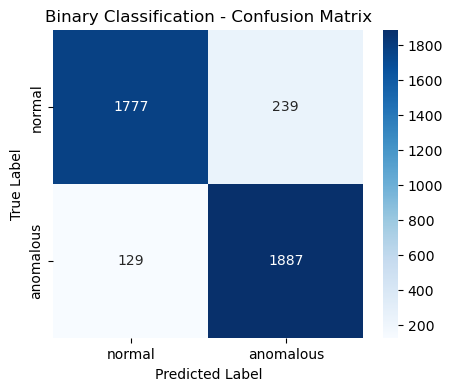

In [34]:
fig_bin, ax_bin = plt.subplots(figsize=(5,4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal','anomalous'], yticklabels=['normal','anomalous'], ax=ax_bin)
ax_bin.set_xlabel('Predicted Label')
ax_bin.set_ylabel('True Label')
ax_bin.set_title('Binary Classification - Confusion Matrix')
plt.show()

In [42]:
predictions_bin = np.asarray(predictions_bin, dtype=np.int64) 

test_idx_bin = datasets_binary["test_idx"]           
meta_test_bin = seg_meta_df.loc[test_idx_bin].copy()
meta_test_bin["binary_prediction"] = predictions_bin
assert len(predictions_bin) == meta_test_bin.shape[0]

# human‑readable version
meta_test_bin["binary_prediction_state"] = np.where(
    predictions_bin == 0, "normal", "anomalous"
)

bin_path = os.path.join(base_dir, "segments_metadata_test_binary_pred.csv")
meta_test_bin.to_csv(bin_path, index=True)
print(f"Binary test predictions saved to: {bin_path}")

Binary test predictions saved to: ../dataset/engine_2/segments_metadata_test_binary_pred.csv


### Multiclass Classification

In [35]:
# Train ResNet for Multiclass Classification
num_classes_multi = len(datasets_multi['label_encoder'].classes_)
model_multi = ResNet(ResidualBlock, [2, 2, 2, 2], num_classes=num_classes_multi, block_kwargs={'use_se': False}).to(device)
print("Training ResNet for multiclass classification...")
model_multi = train_resnet_model(model_multi, train_loader_multi, val_loader=val_loader_multi, device=device, num_epochs=num_epochs_multi)

Training ResNet for multiclass classification...


Epoch 1/20:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch [1/20], Loss: 1.0042
Validation Loss: 1.2574, Accuracy: 33.33%
[✓]   New best (multiclass) saved →  ../res/checkpoints/resnet_best_multiclass.pth  (metric=0.3333)
→ New best model saved


Epoch 2/20:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch [2/20], Loss: 0.5047
Validation Loss: 3.4439, Accuracy: 33.33%


...

Epoch [18/20], Loss: 0.0097
Validation Loss: 0.6228, Accuracy: 80.92%


Epoch 19/20:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch [19/20], Loss: 0.0052
Validation Loss: 0.5460, Accuracy: 81.93%


Epoch 20/20:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch [20/20], Loss: 0.0097
Validation Loss: 1.2168, Accuracy: 54.30%


In [36]:
# Save label encoder
import joblib

enc = datasets_multi["label_encoder"]
save_dir = Path("../res/label_encoders")
save_dir.mkdir(parents=True, exist_ok=True)

enc_path = save_dir / "label_encoder_multiclass.pkl"
joblib.dump(enc, enc_path, compress=3)

print(f"[✓]  Saved LabelEncoder with classes → {list(enc.classes_)}\n"
      f"     to {enc_path.resolve()}")

[✓]  Saved LabelEncoder with classes → ['inter-turn short circuits', 'normal', 'rotor bar defect']
     to /Users/kgb/Yandex.Disk.localized/Code/Motor-Fault-Detection/res/label_encoders/label_encoder_multiclass.pkl


In [37]:
true_labels_multi, predictions_multi = inference_resnet_model(model_multi, test_loader_multi, device=device)

Inference:   0%|          | 0/12 [00:00<?, ?batch/s]

In [38]:
# Calculate metrics 
cm_multi, acc_multi, prec_multi, rec_multi, f1_multi = calculate_metrics(true_labels_multi, predictions_multi)

In [39]:
multiclass_report = classification_report(true_labels_multi, predictions_multi, target_names=datasets_multi['label_encoder'].classes_, output_dict=True)
multiclass_report_prefixed = {f"multiclass_{key}": value for key, value in multiclass_report.items()}

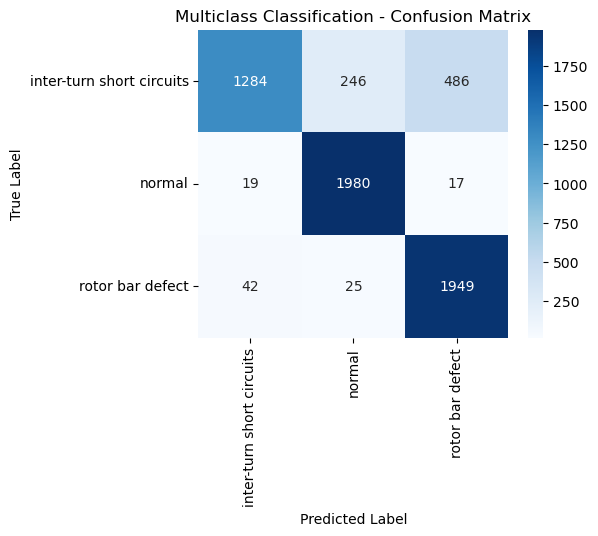

In [40]:
fig_multi, ax_multi = plt.subplots(figsize=(5,4))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=datasets_multi['label_encoder'].classes_,
            yticklabels=datasets_multi['label_encoder'].classes_, ax=ax_multi)
ax_multi.set_xlabel('Predicted Label')
ax_multi.set_ylabel('True Label')
ax_multi.set_title('Multiclass Classification - Confusion Matrix')
plt.show()

In [41]:
predictions_multi = np.asarray(predictions_multi, dtype=np.int64) 

test_idx_multi = datasets_multi["test_idx"]
meta_test_multi = seg_meta_df.loc[test_idx_multi].copy()
assert len(predictions_multi) == meta_test_multi.shape[0]

# decode integer predictions back to fault names
pred_labels_multi = datasets_multi["label_encoder"].inverse_transform(predictions_multi)
meta_test_multi["multiclass_prediction"] = pred_labels_multi

multi_path = os.path.join(base_dir, "segments_metadata_test_multiclass_pred.csv")
meta_test_multi.to_csv(multi_path, index=True)
print(f"Multiclass test predictions saved to: {multi_path}")

Multiclass test predictions saved to: ../dataset/engine_2/segments_metadata_test_multiclass_pred.csv
